## Problem 1. Random Number Generators


#### LCG implementation

In [1]:

class LCG:
    def __init__(self, a: float, c: float, d: float, seed: float = 42) -> None:
        """Init LCG."""
        assert a > 0 and c > 0 and d > 0, "a, c, d must be positive"
        assert 0 < seed < d, "seed must be in [0, d)"
        assert a < d and c < d, "a, c must be less than d"

        self.a = a
        self.c = c
        self.d = d
        self.state = seed

    def next(self) -> float:
        """Generate next number in sequence from Uniform(0, 1)."""
        self.state = (self.a * self.state + self.c) % self.d

        return self.state / self.d

    def get_list(self, size: int, seed: float | None = None) -> list[float]:
        """Generate list of numbers."""
        if seed is not None:
            self.state = seed

        return [self.next() for _ in range(size)]


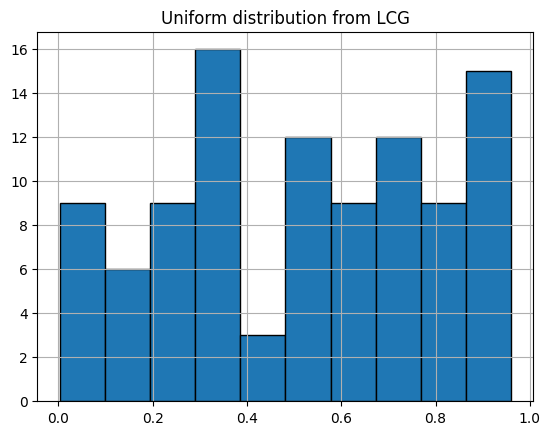

In [2]:
from matplotlib import pyplot as plt

rng = LCG(a=256, c=133, d=299, seed=1)

uniform = rng.get_list(100)

plt.hist(uniform, bins=10, edgecolor="black")
plt.title("Uniform distribution from LCG")
plt.grid(True)
plt.show()


#### Numpy samples

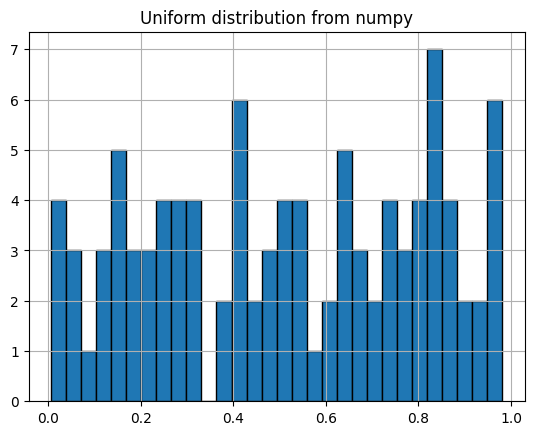

In [3]:
import numpy as np

rng_np = np.random.default_rng(1)

uniform_np = rng_np.uniform(size=100)

plt.hist(uniform_np, bins=30, edgecolor="black")
plt.title("Uniform distribution from numpy")
plt.grid(True)
plt.show()


#### Plot probability density functions and calculate the first 4 moments (mean, variance, skewness, kurtosis)

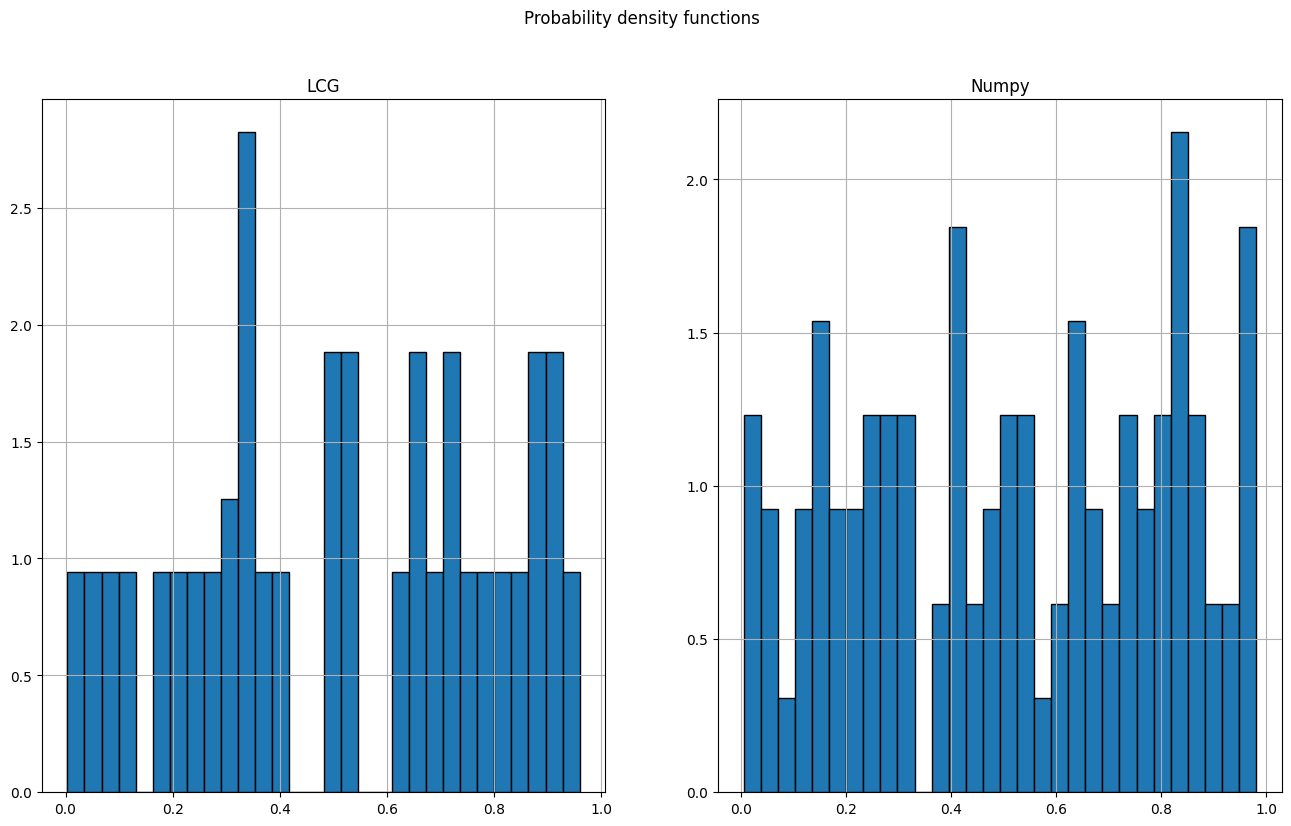

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))

fig.suptitle("Probability density functions")

ax2.hist(uniform_np, bins=30, density=True, edgecolor="black")
ax2.set_title("Numpy")
ax2.grid(True)

ax1.hist(uniform, bins=30, density=True, edgecolor="black")
ax1.set_title("LCG")
ax1.grid(True)

plt.show()

In [5]:
def mean(x: list[float]) -> float:
    return sum(x) / len(x)

def variance(x: list[float]) -> float:
    m = mean(x)
    return sum((x_ - m) ** 2 for x_ in x) / len(x)

def skewness(x: list[float]) -> float:
    m = mean(x)
    return sum((x_  - m) ** 3 for x_ in x) / ((len(x) * variance(x)) ** 1.5)

def kurtosis(x: list[float]) -> float:
    m = mean(x)
    return sum((x_ - m) ** 4 for x_ in x) / (len(x) * (variance(x) ** 2)) - 3

print("True values:")
print("Mean: ", 0.5)
print("Variance: ", 1/12)
print("Skewness: ", 0)
print("Kurtosis: ", -6/5)
print("-" * 100)
print("LCG:")
print("Mean: ", mean(uniform), "difference: ", abs(mean(uniform) - 0.5))
print("Variance: ", variance(uniform), "difference: ", abs(variance(uniform) - 1/12))
print("Skewness: ", skewness(uniform), "difference: ", abs(skewness(uniform) - 0))
print("Kurtosis: ", kurtosis(uniform), "difference: ", abs(kurtosis(uniform) - -6/5))
print("-" * 100)
print("Numpy:")
print("Mean: ", mean(uniform_np), "difference: ", abs(mean(uniform_np) - 0.5))
print("Variance: ", variance(uniform_np), "difference: ", abs(variance(uniform_np) - 1/12))
print("Skewness: ", skewness(uniform_np), "difference: ", abs(skewness(uniform_np) - 0))
print("Kurtosis: ", kurtosis(uniform_np), "difference: ", abs(kurtosis(uniform_np) - -6/5))
print("-" * 100)


True values:
Mean:  0.5
Variance:  0.08333333333333333
Skewness:  0
Kurtosis:  -1.2
----------------------------------------------------------------------------------------------------
LCG:
Mean:  0.5155183946488294 difference:  0.015518394648829426
Variance:  0.07950403686759656 difference:  0.0038292964657367645
Skewness:  -0.013206542296184995 difference:  0.013206542296184995
Kurtosis:  -1.2158038451053443 difference:  0.015803845105344383
----------------------------------------------------------------------------------------------------
Numpy:
Mean:  0.5130689695707583 difference:  0.013068969570758315
Variance:  0.0823925236294121 difference:  0.0009408097039212276
Skewness:  -0.009523960410602161 difference:  0.009523960410602161
Kurtosis:  -1.2488585828837862 difference:  0.048858582883786195
----------------------------------------------------------------------------------------------------


According to our comparison, almost all moments of numpy distribution is closer to the true uniform distribution moments, except of Kurtosis parameter. So, numpy provide closer approximation of samples from uniform distribution.

#### ACF

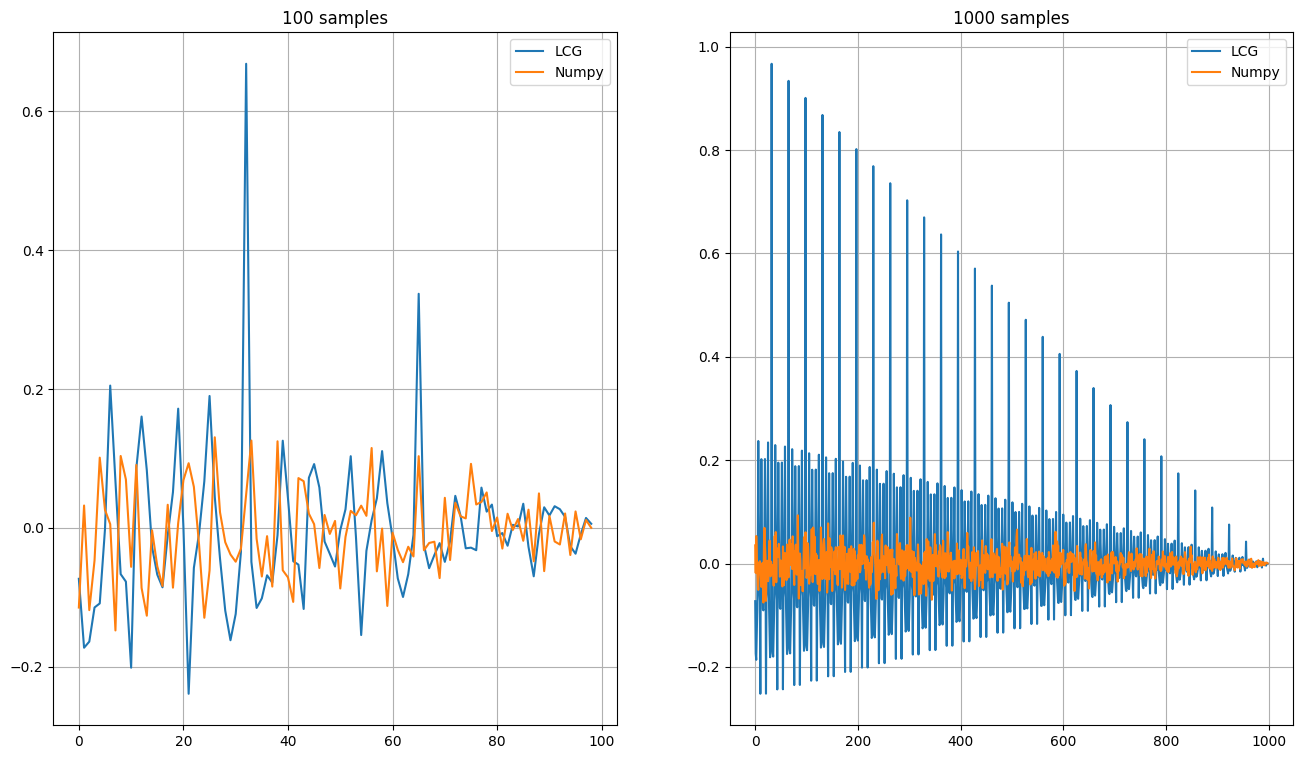

In [6]:
def acf(x: list[float], k: int) -> list[float]:
    m = mean(x)
    var = variance(x)

    return sum([(x[i] - m) * (x[i+k] - m) for i in range(len(x) - k)]) / (var * len(x))


fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16, 9))

ax1.plot([acf(uniform, k) for k in range(1, len(uniform))], label="LCG")
ax1.plot([acf(uniform_np, k) for k in range(1, len(uniform_np))], label="Numpy")
ax1.set_title("100 samples")
ax1.legend()
ax1.grid(True)

uniform_1000 = rng.get_list(1000)
uniform_np_1000 = rng_np.uniform(size=1000)

ax2.plot([acf(uniform_1000, k) for k in range(1, len(uniform_1000))], label="LCG")
ax2.plot([acf(uniform_np_1000, k) for k in range(1, len(uniform_np_1000))], label="Numpy")
ax2.set_title("1000 samples")
ax2.legend()
ax2.grid(True)
plt.show()


This two plots for 100 and 100 samples seems the same, but in plot for the 1000 samples we can see periodical decaying trend.

##### Spectral test

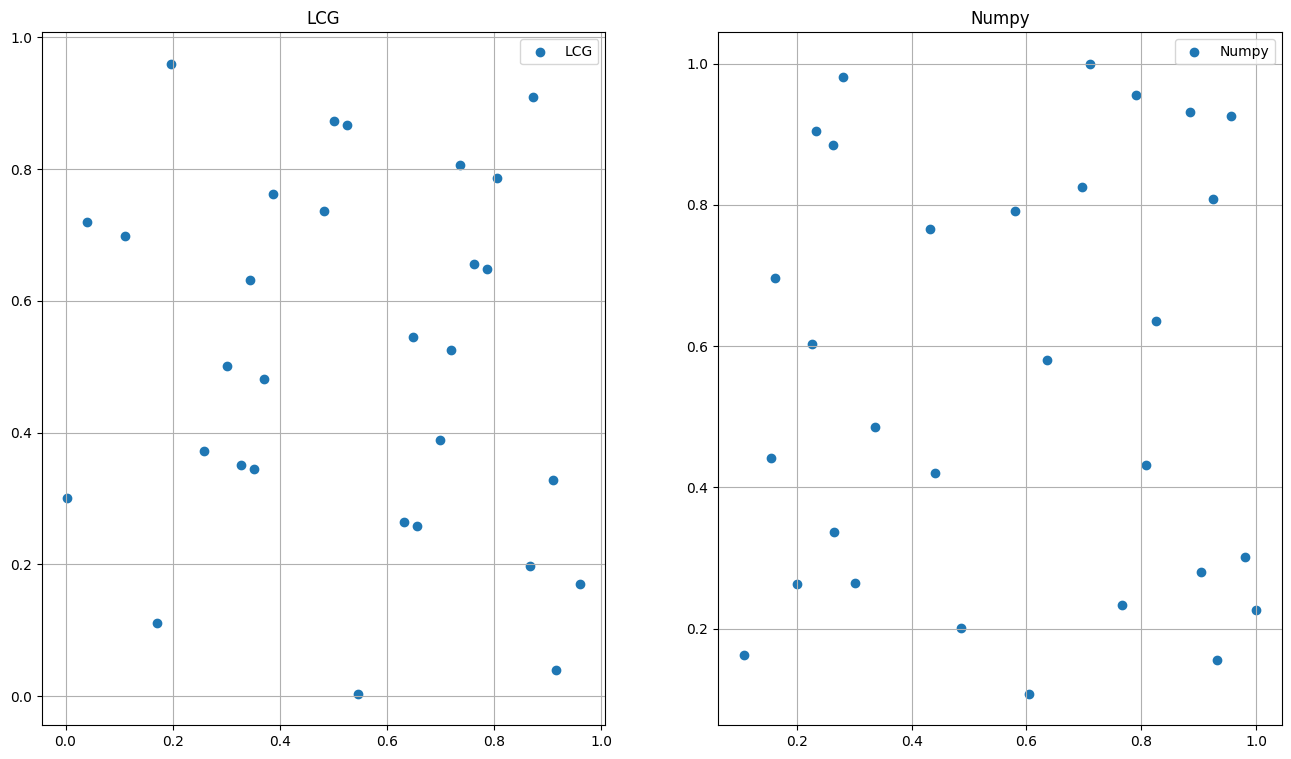

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16, 9))


uniform_31 = rng.get_list(31)
uniform_np_31 = rng_np.uniform(size=31)

ax1.scatter(uniform_31[:-1], uniform_31[1:], label="LCG")
ax1.set_title("LCG")
ax1.legend()
ax1.grid(True)

ax2.scatter(uniform_np_31[:-1], uniform_np_31[1:], label="Numpy")
ax2.set_title("Numpy")
ax2.legend()
ax2.grid(True, which='both')
plt.show()

As it hard to recognize planes by eyes, lets provide the algorithm to compute the maximum gap between them. The main idea of the algorithm is the following

1. Construct d-tuples from samples
2. Construct several directions in space using $n$ vectors
3. Project all points onto direction defined by certain vector 
4. Find the largest gap in theprojection
5. The maximum over all $n$ = spectral gap

In uniform case, $gap \approx \frac{1}{N^{1/d}}$, where $N$ - number of samples and $d$ - dimension

In [8]:
import numpy as np
from itertools import product

def tuples_from_seq(u, d):
    """Construct tuples from generated samples."""
    u = np.asarray(u)
    N = len(u) - d + 1
    X = np.column_stack([u[i:i+N] for i in range(d)])

    return X

def spectral_gap(X, max_coeff=6):
    """Compute the spectral gap for a given set of points."""
    N, d = X.shape
    max_gap = 0.0
    max_n = None
    coeffs = range(-max_coeff, max_coeff + 1)

    #product - constructing all possible directions
    for n_tuple in product(coeffs, repeat=d):
        if all(c == 0 for c in n_tuple):
            continue

        n = np.array(n_tuple, dtype=int)
        #gcd - to reduce the number of duplicates (e.g. [1,2,3] and [2,4,6] are the same)

        g = np.gcd.reduce(np.abs(n))

        if g > 1:
            continue

        s = (X @ n) % 1.0
        s.sort()
        gaps = np.diff(np.r_[s, s[0] + 1.0])
        gap = gaps.max()

        if gap > max_gap:
            max_gap = gap
            max_n = n.copy()

    return max_gap, max_n


X2 = tuples_from_seq(uniform, d=2)
gap2, n2 = spectral_gap(X2, max_coeff=6)
expected_gap2 = 1 / len(uniform) ** (1/2)
planes2 = 1.0 / gap2

X3 = tuples_from_seq(uniform, d=3)
gap3, n3 = spectral_gap(X3, max_coeff=6)
expected_gap3 = 1 / len(uniform) ** (1/3)
planes3 = 1.0 / gap3

X4 = tuples_from_seq(uniform, d=4)
gap4, n4 = spectral_gap(X4, max_coeff=6)
expected_gap4 = 1 / len(uniform) ** (1/4)
planes4 = 1.0 / gap4

print(f"2D: delta={gap2:.6f}, ~planes={planes2:.1f}, exp gap={expected_gap2:.6f}, normal={n2}")
print(f"3D: delta={gap3:.6f}, ~planes={planes3:.1f}, exp gap={expected_gap3:.6f}, normal={n3}")
print(f"4D: delta={gap4:.6f}, ~planes={planes4:.1f}, exp gap={expected_gap4:.6f}, normal={n4}")

2D: delta=0.692308, ~planes=1.4, exp gap=0.100000, normal=[-3  1]
3D: delta=1.000000, ~planes=1.0, exp gap=0.215443, normal=[-5  3 -3]
4D: delta=1.000000, ~planes=1.0, exp gap=0.316228, normal=[-2  0  4  3]


As we can observe, gaps is far away from theoretical and it shows, that LCD with parameters is quiet bad.

Lets compare with the numpy resutls

In [9]:
X2 = tuples_from_seq(uniform_np, d=2)
gap2, n2 = spectral_gap(X2, max_coeff=4)
planes2 = 1.0 / gap2

X3 = tuples_from_seq(uniform_np, d=3)
gap3, n3 = spectral_gap(X3, max_coeff=4)
planes3 = 1.0 / gap3

X4 = tuples_from_seq(uniform_np, d=4)
gap4, n4 = spectral_gap(X4, max_coeff=4)  # may reduce for speed
planes4 = 1.0 / gap4

print(f"2D: delta={gap2:.6f}, ~planes={planes2:.1f}, normal={n2}")
print(f"3D: delta={gap3:.6f}, ~planes={planes3:.1f}, normal={n3}")
print(f"4D: delta={gap4:.6f}, ~planes={planes4:.1f}, normal={n4}")

2D: delta=0.106324, ~planes=9.4, normal=[-1 -1]
3D: delta=0.106324, ~planes=9.4, normal=[-1 -1  0]
4D: delta=0.106324, ~planes=9.4, normal=[-1 -1  0  0]


As we see, the delta for numpy is less than expected, and it is small number, that can proof, that numpy is good enough.

## Problem 2.

#### 1.

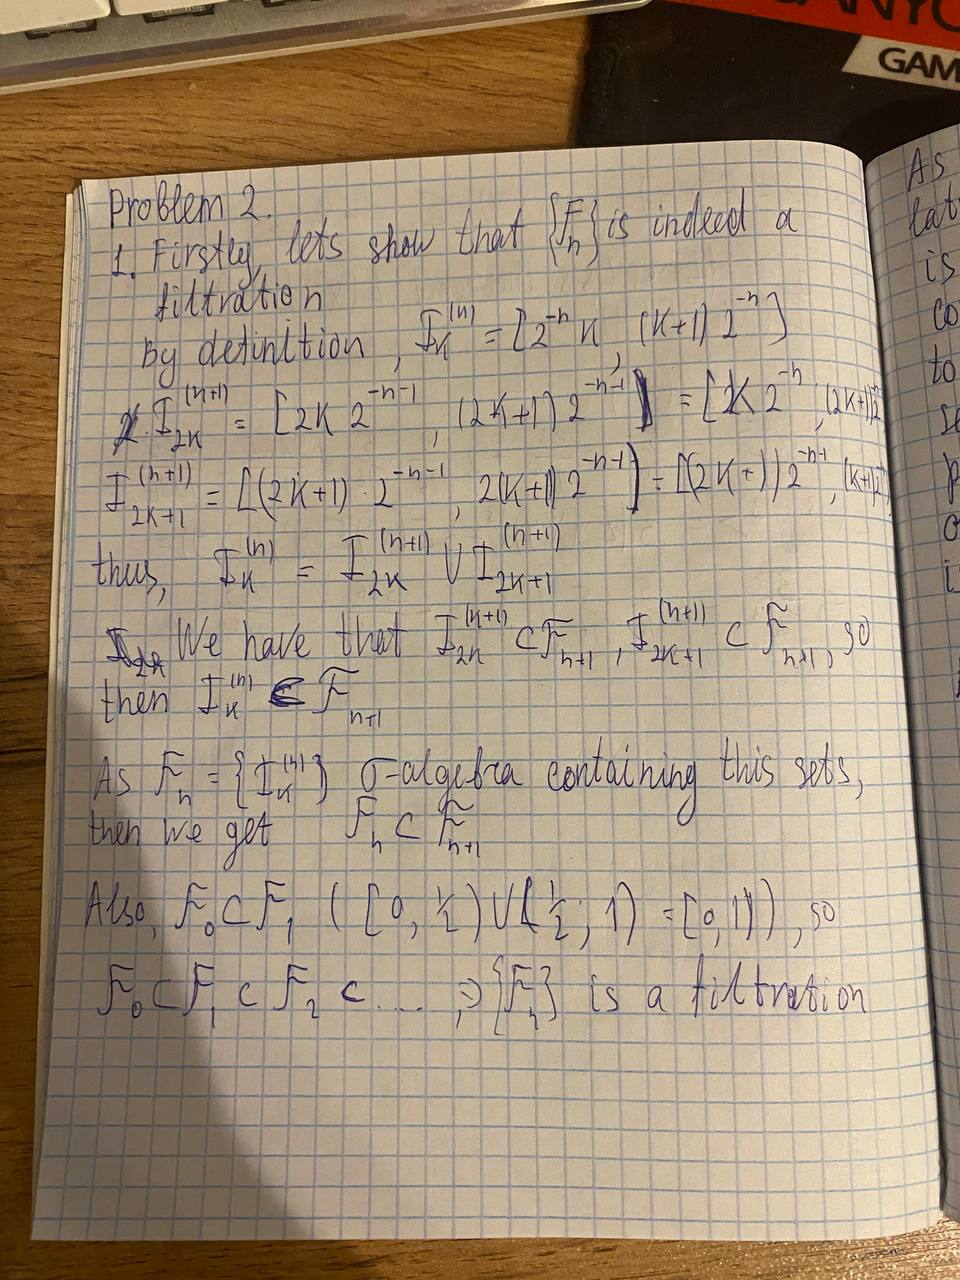

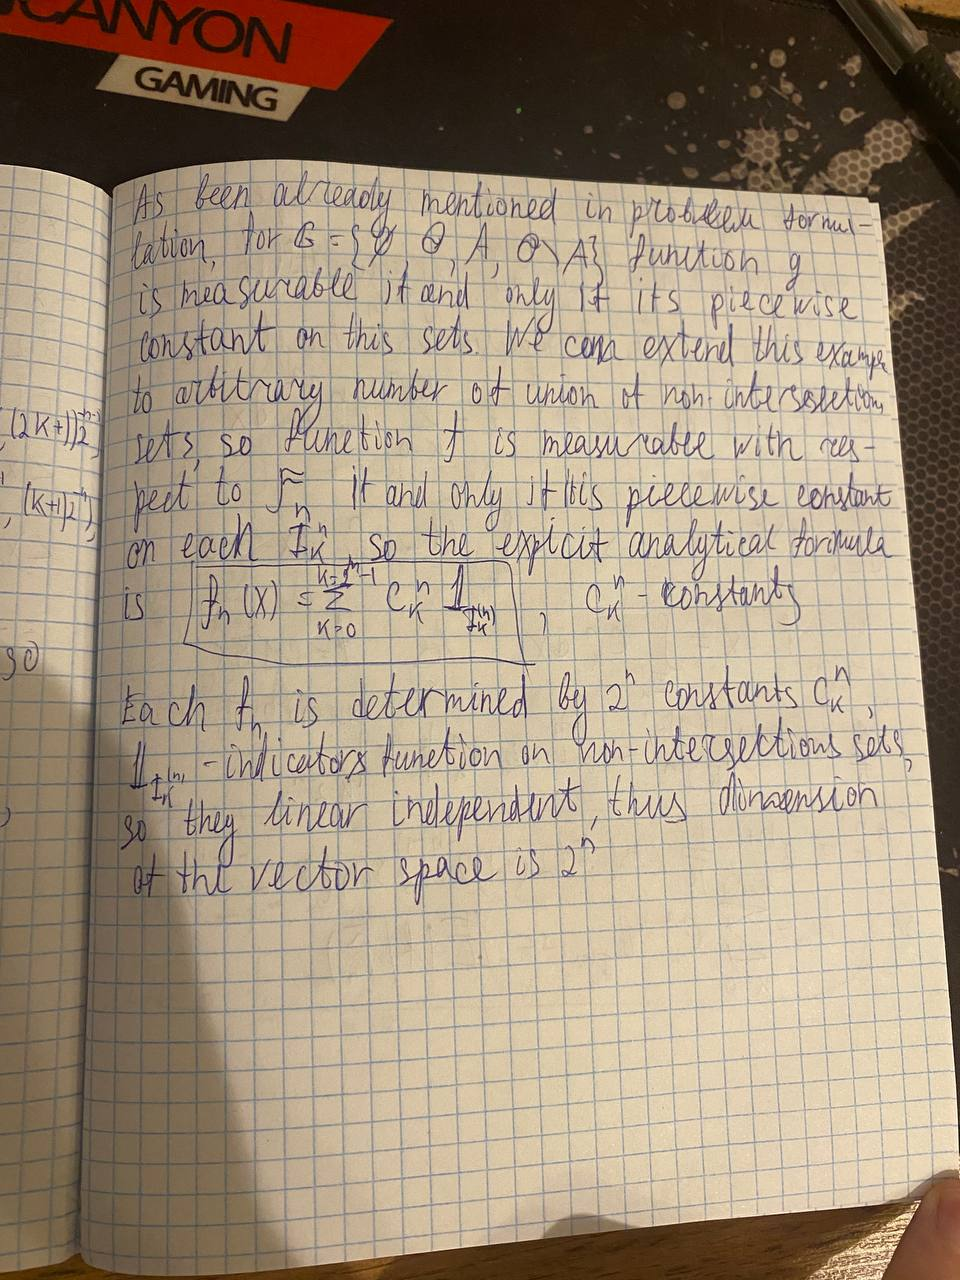

#### 2.

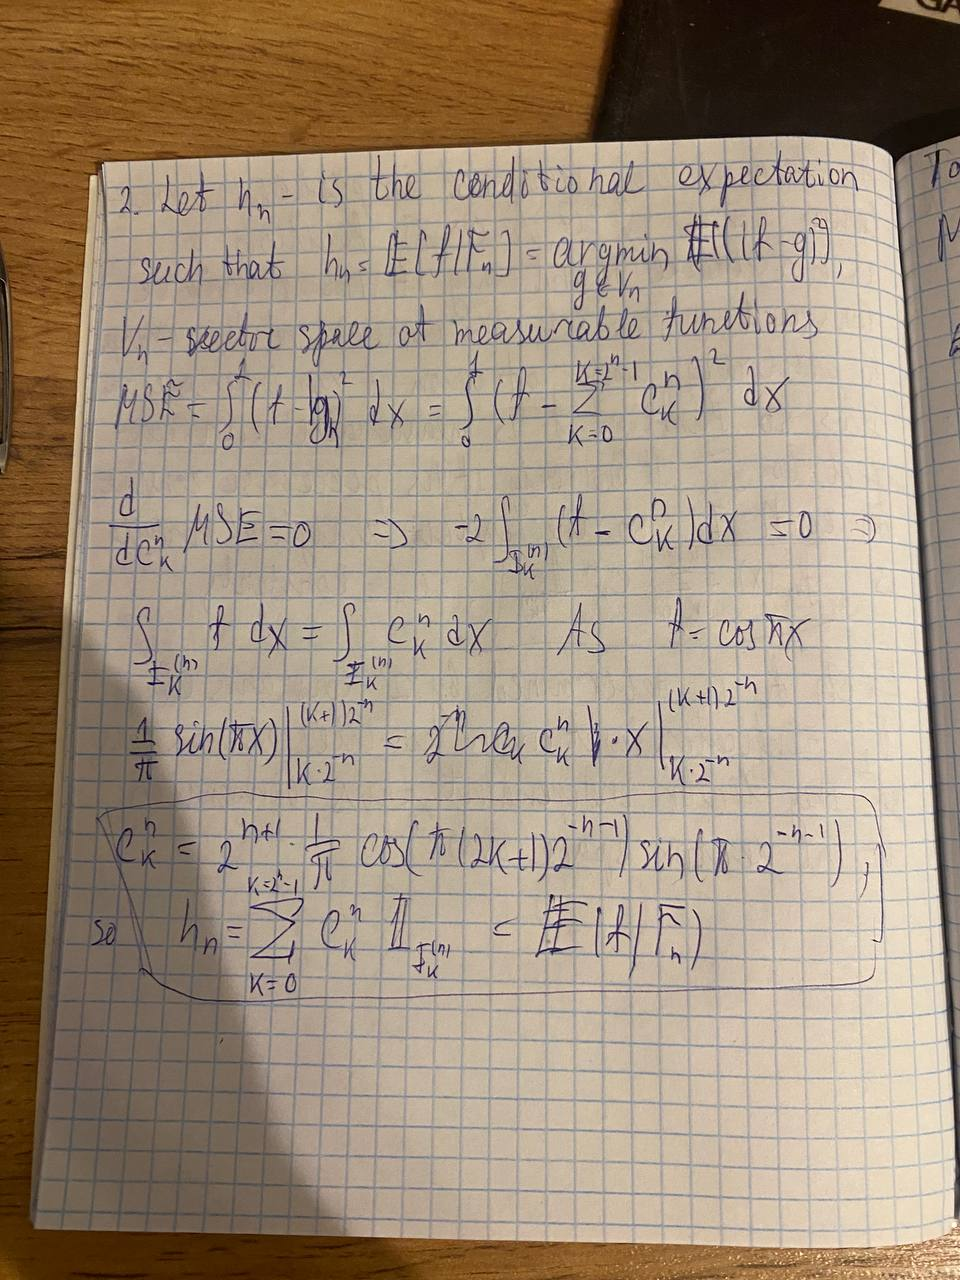

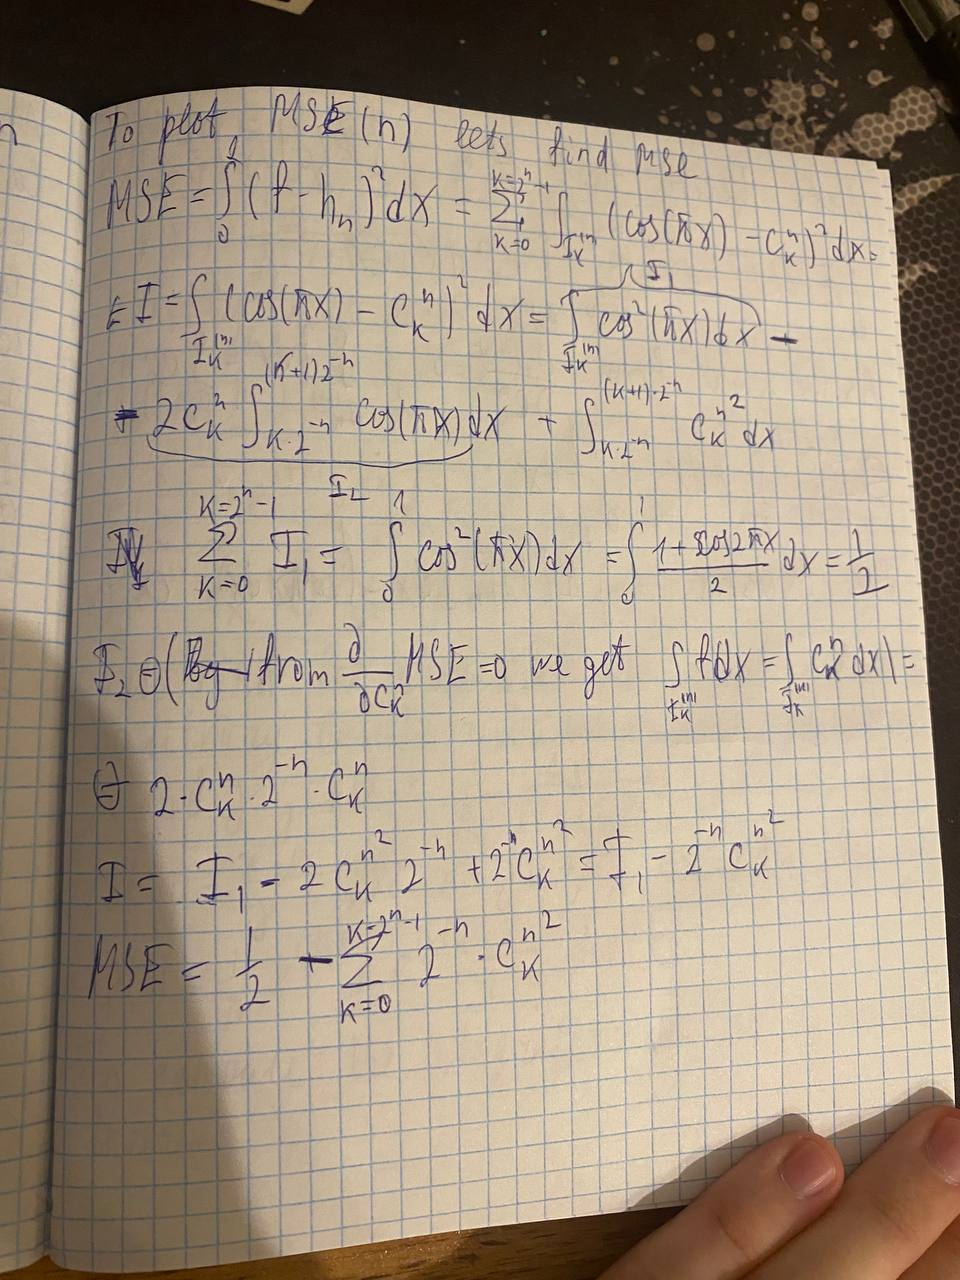

Computing MSE for n =  0
Computing MSE for n =  1
Computing MSE for n =  2
Computing MSE for n =  3
Computing MSE for n =  4


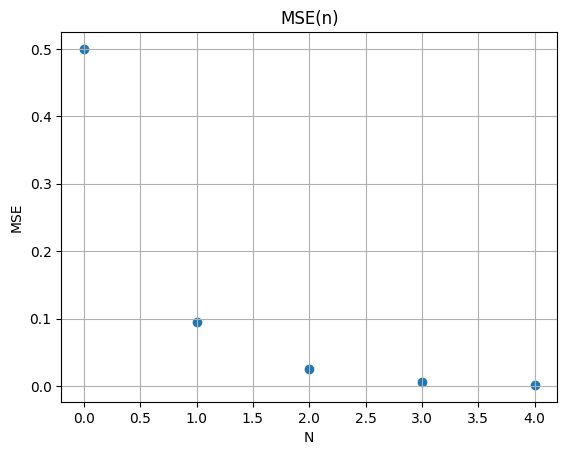

In [10]:
#Plot MSE
import numpy as np
import matplotlib.pyplot as plt


def mse(n: int) -> float:
    """Compute MSE."""
    if n < 0:
        return 0

    print("Computing MSE for n = ", n)

    mse: float = 0.5
    k_max: int = 2**n

    for k in range(k_max):
        mse_part: float = np.cos(np.pi * (2*k + 1) / 2**(n  + 1)) * np.sin(np.pi / 2**(n  + 1))
        mse_part_2: float = 2**(n + 2) / np.pi**2  * mse_part * mse_part
        mse -= mse_part_2

    return mse


x = [i for i in range(5)]
y = [mse(i) for i in x]

plt.scatter(x, y)
plt.grid()
plt.xlabel("N")
plt.ylabel("MSE")
plt.title("MSE(n)")
plt.show()


As we can see, the MSE decrease. Now lets plot the first four conditional expectations

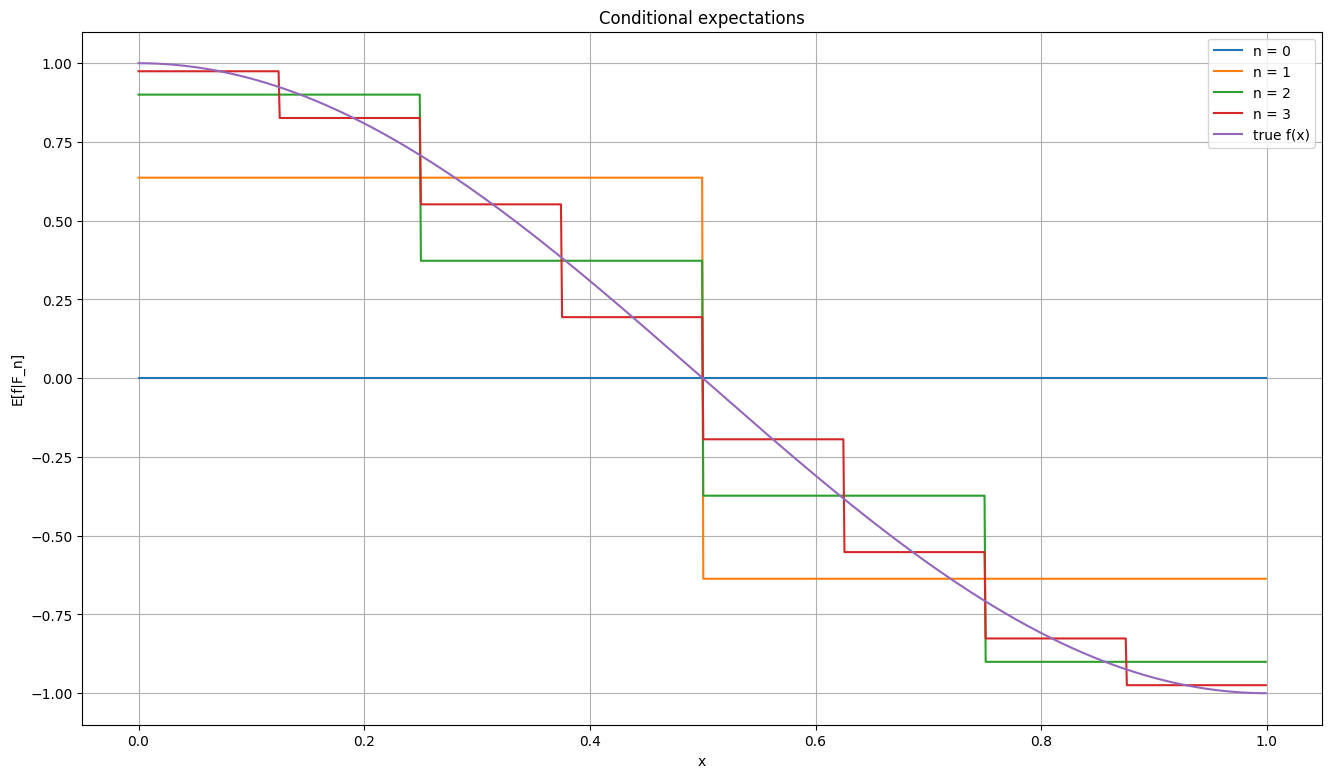

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def e_n(n: int) -> tuple[np.ndarray, np.ndarray]:
    """Compute expectation."""
    k_max: int = 2**n
    x: np.ndarray = np.linspace(0, 1, 1000)
    e_n: np.ndarray = np.zeros(x.shape)

    for k in range(k_max):

        mask = (x >= k * 2**(-n)) & (x < (k + 1) * 2**(-n))
        e_n[mask] = 2**(n + 1) *np.cos(np.pi * (2*k + 1) / 2**( n + 1)) * np.sin(np.pi / 2**(n + 1)) / np.pi

    return x[:-1], e_n[:-1]



plt.figure(figsize=(16, 9))

for n in range(0, 4):
    x, e = e_n(n)
    plt.plot(x, e, label=f"n = {n}")

plt.plot(x, np.cos(np.pi * x), label="true f(x)")
plt.grid()
plt.title("Conditional expectations")
plt.xlabel("x")
plt.ylabel("E[f|F_n]")
plt.legend()
plt.show()




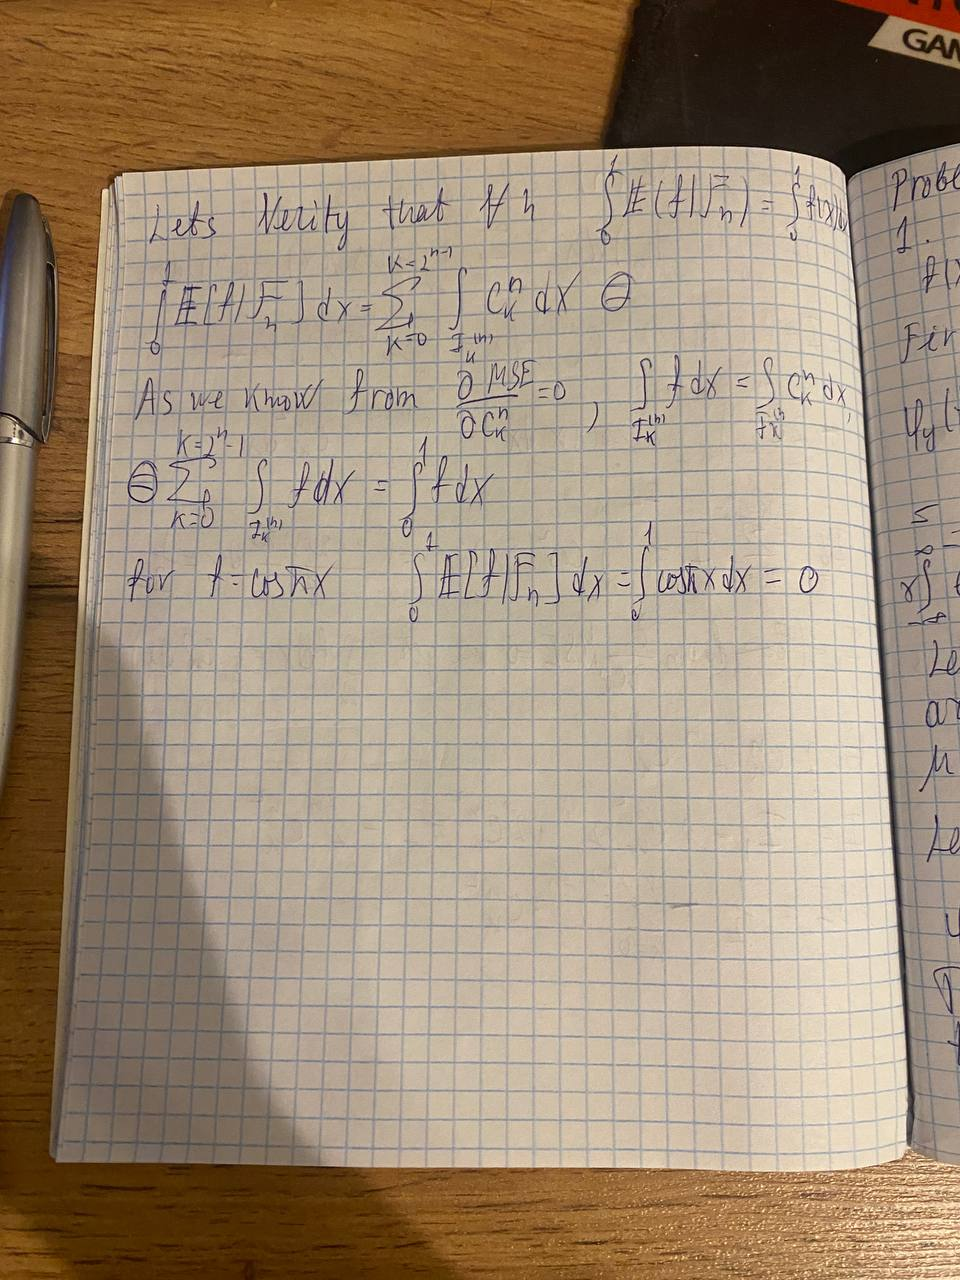

## Problem 3

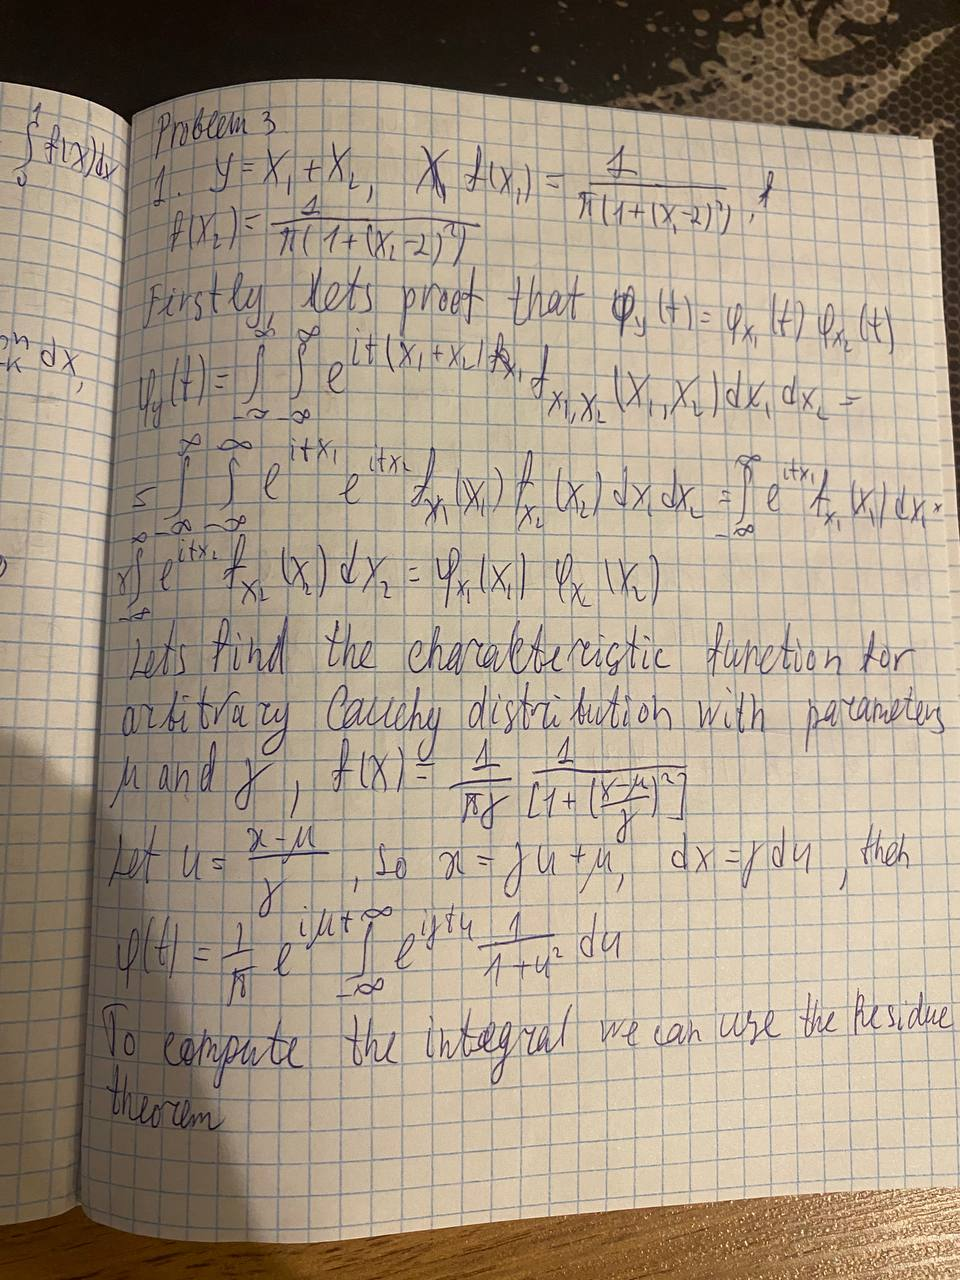

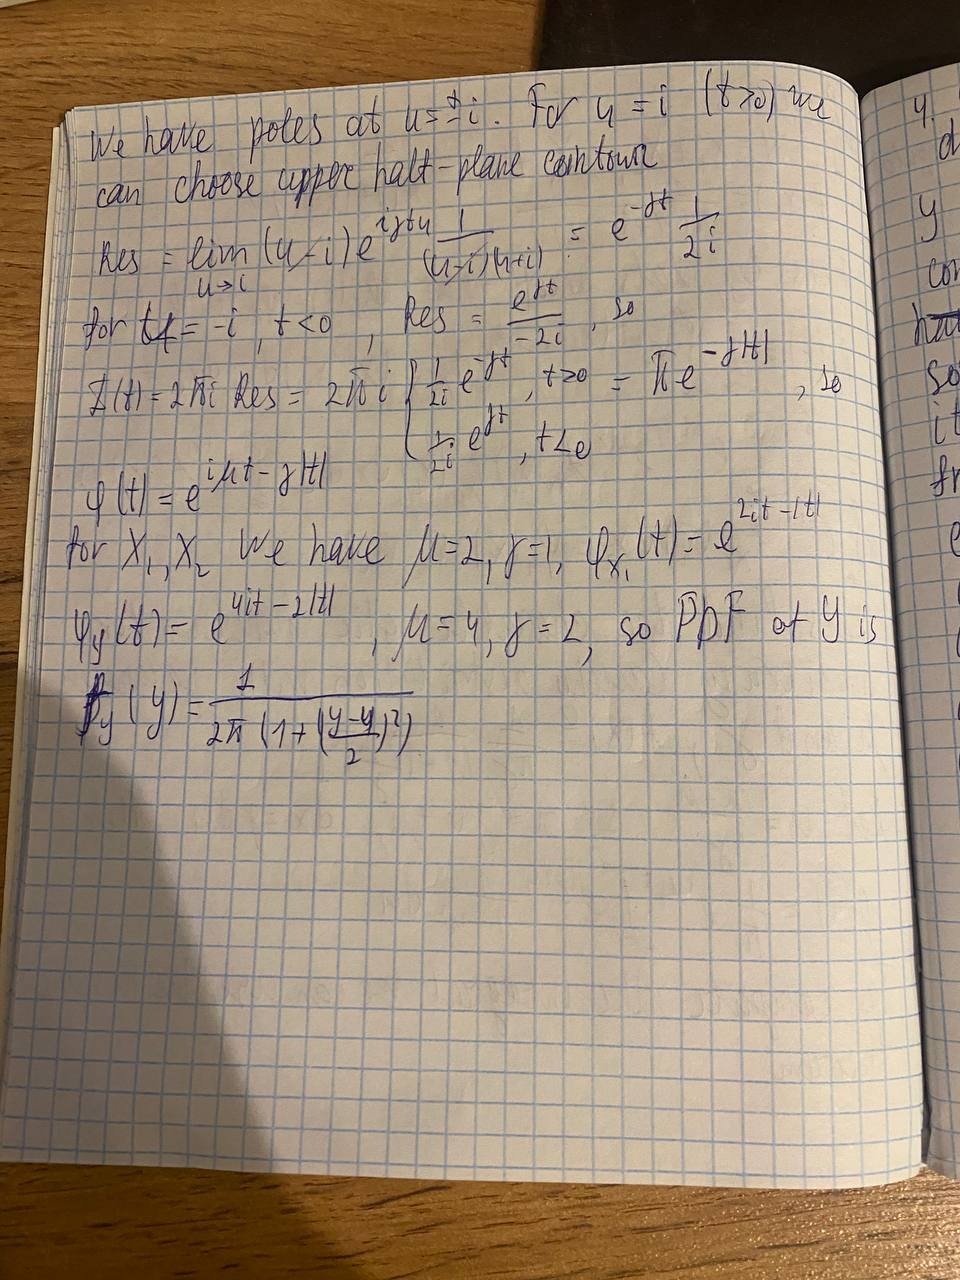

#### Sample  40000 values for both $X_1$ and $X_2$. Plot a histogram. Check the correspondence.

Firstly, lets define the formula for the sample from arbitrary Cauchy distribution generated from uniform distribution. By integrating the PDF, we get the CDF: $$F(x) = \frac{1}{\pi} arctg(\frac{x - \mu}{\gamma}) + \frac{1}{2}$$

Using the result that $x = F^{-1}(u)$, where $u$ is the sample from uniform distribution, we get that $$x = \gamma tg(\pi (u - \frac{1}{2})) + \mu$$

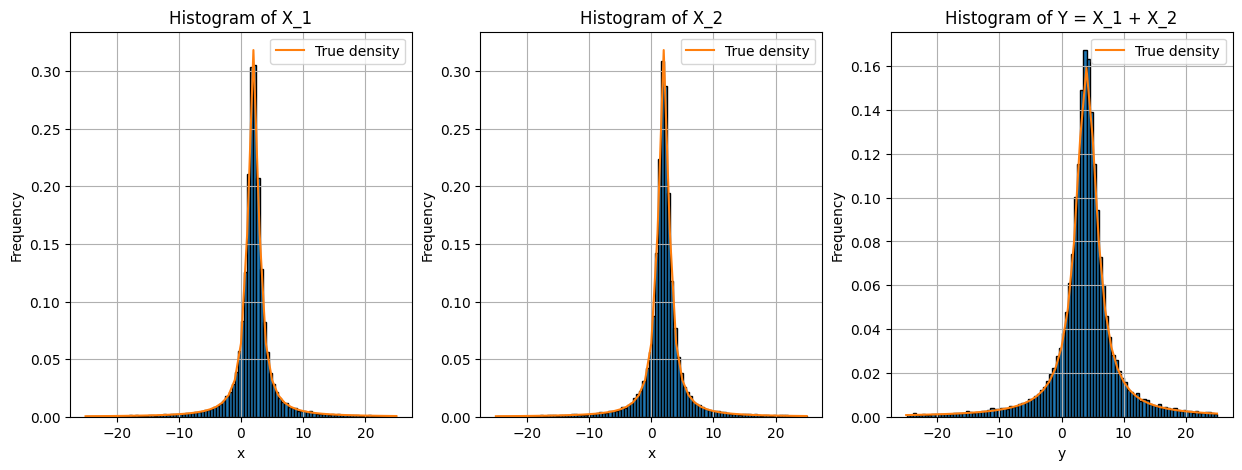

In [12]:
import numpy as np
import matplotlib.pyplot as plt

class CauchyDistribution:
    """Cauchy distribution with parameters mu and gamma."""

    def __init__(self, mu: float, gamma: float) -> None:
        self.mu = mu
        self.gamma = gamma
        self.rng = np.random.default_rng()

    def sample(self, size: int) -> np.ndarray:
        u = self.rng.uniform(0, 1, size)
        return self.gamma * np.tan(np.pi * (u - 0.5)) + self.mu

    def density(self, x: np.ndarray, mu: float | None = None, gamma: float | None = None) -> np.ndarray:

        if mu is None:
            mu = self.mu

        if gamma is None:
            gamma = self.gamma

        return 1 / (1 + ((x - mu) / gamma)**2) / np.pi / gamma


x1_rng = CauchyDistribution(mu=2, gamma=1)
x2_rng = CauchyDistribution(mu=2, gamma=1)

x1_samples = x1_rng.sample(40000)
x2_samples = x2_rng.sample(40000)
y_samples = x1_samples + x2_samples

x_plot = np.arange(start=-25, stop=26)
x1_density = x1_rng.density(x_plot)
x2_density = x2_rng.density(x_plot)
y_density = x2_rng.density(x_plot, mu=4, gamma=2)


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.hist(x1_samples[(x1_samples > -25) & (x1_samples < 25)], density=True, bins=100, edgecolor="black")
ax1.plot(x_plot, x1_density, label="True density")
ax1.set_title("Histogram of X_1")
ax1.set_xlabel("x")
ax1.grid(True)
ax1.set_ylabel("Frequency")
ax1.legend()

ax2.hist(x2_samples[(x2_samples > -25) & (x2_samples < 25)], density=True, bins=100, edgecolor="black")
ax2.plot(x_plot, x2_density, label="True density")
ax2.set_title("Histogram of X_2")
ax2.set_xlabel("x")
ax2.grid(True)
ax2.set_ylabel("Frequency")
ax2.legend()

ax3.hist(y_samples[(y_samples > -25) & (y_samples < 25)], density=True, bins=100, edgecolor="black")
ax3.plot(x_plot, y_density, label="True density")
ax3.set_title("Histogram of Y = X_1 + X_2")
ax3.set_xlabel("y")
ax3.grid(True)
ax3.set_ylabel("Frequency")
ax3.legend()
plt.show()




As we can see on histograms, samples fit the distribution. Y matches the theoretical distribution

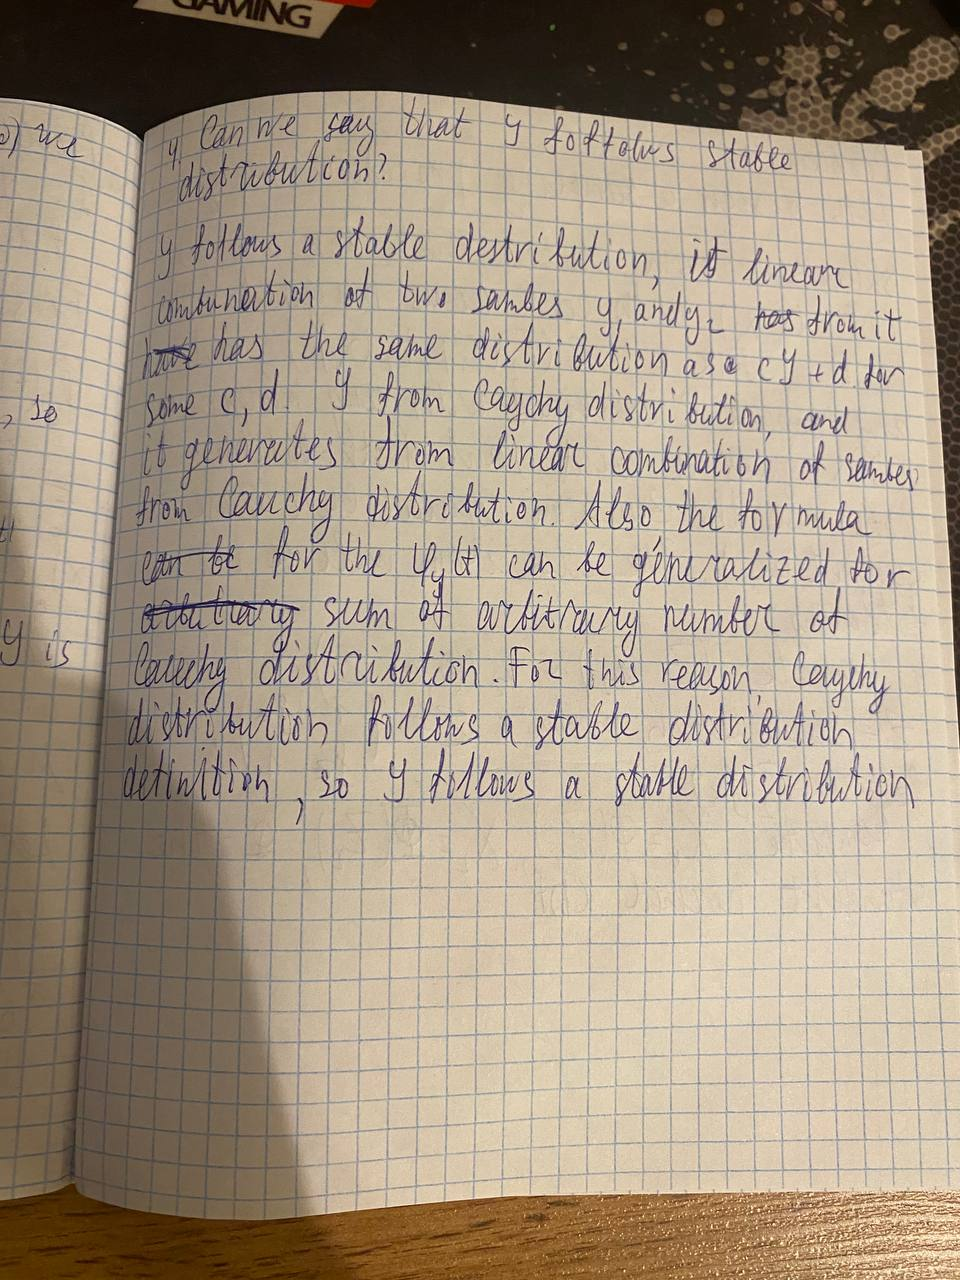

## Problem 4

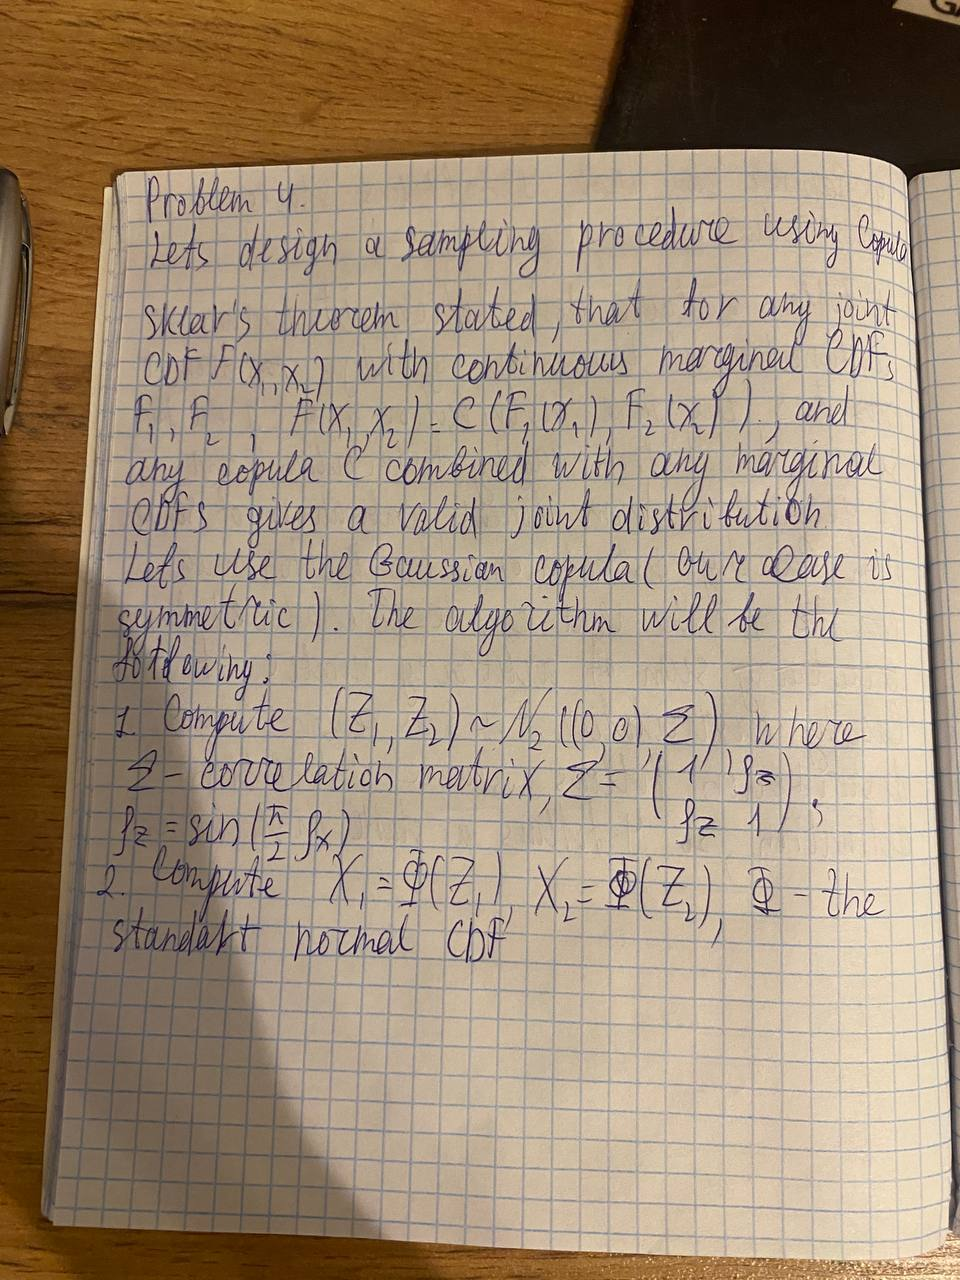

/var/folders/db/zplyd3jx79x674f1sg4mt97c0000gn/T/ipykernel_48236/4206785338.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


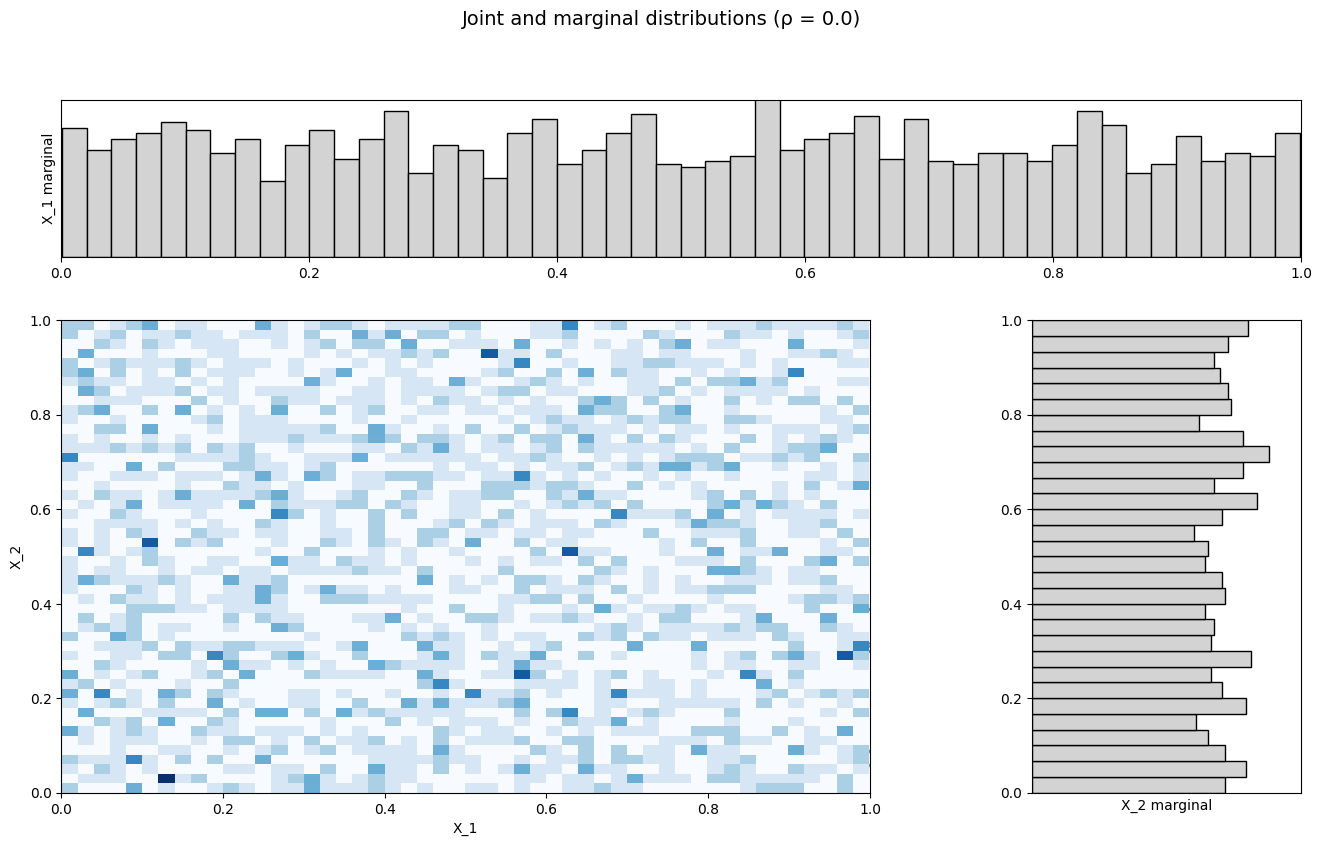

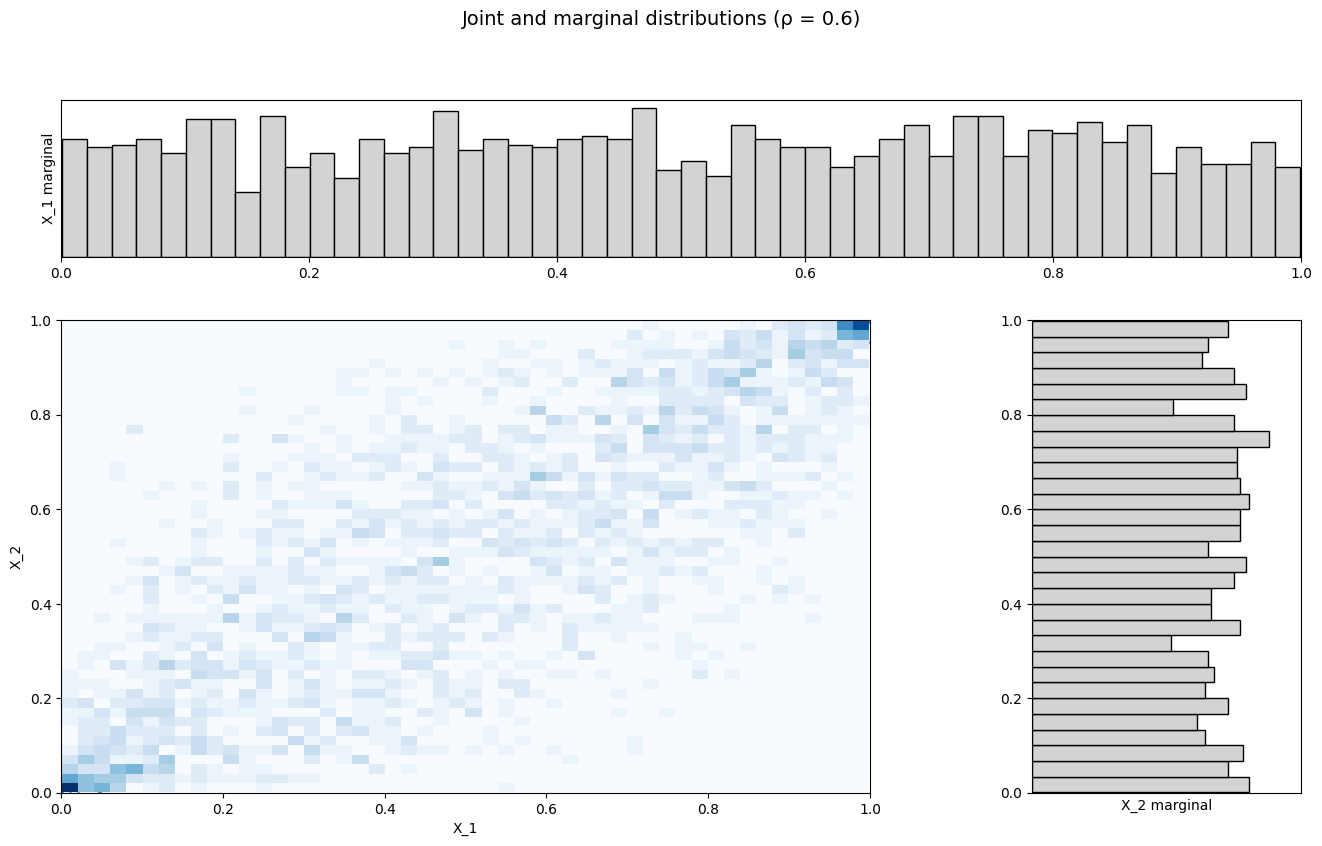

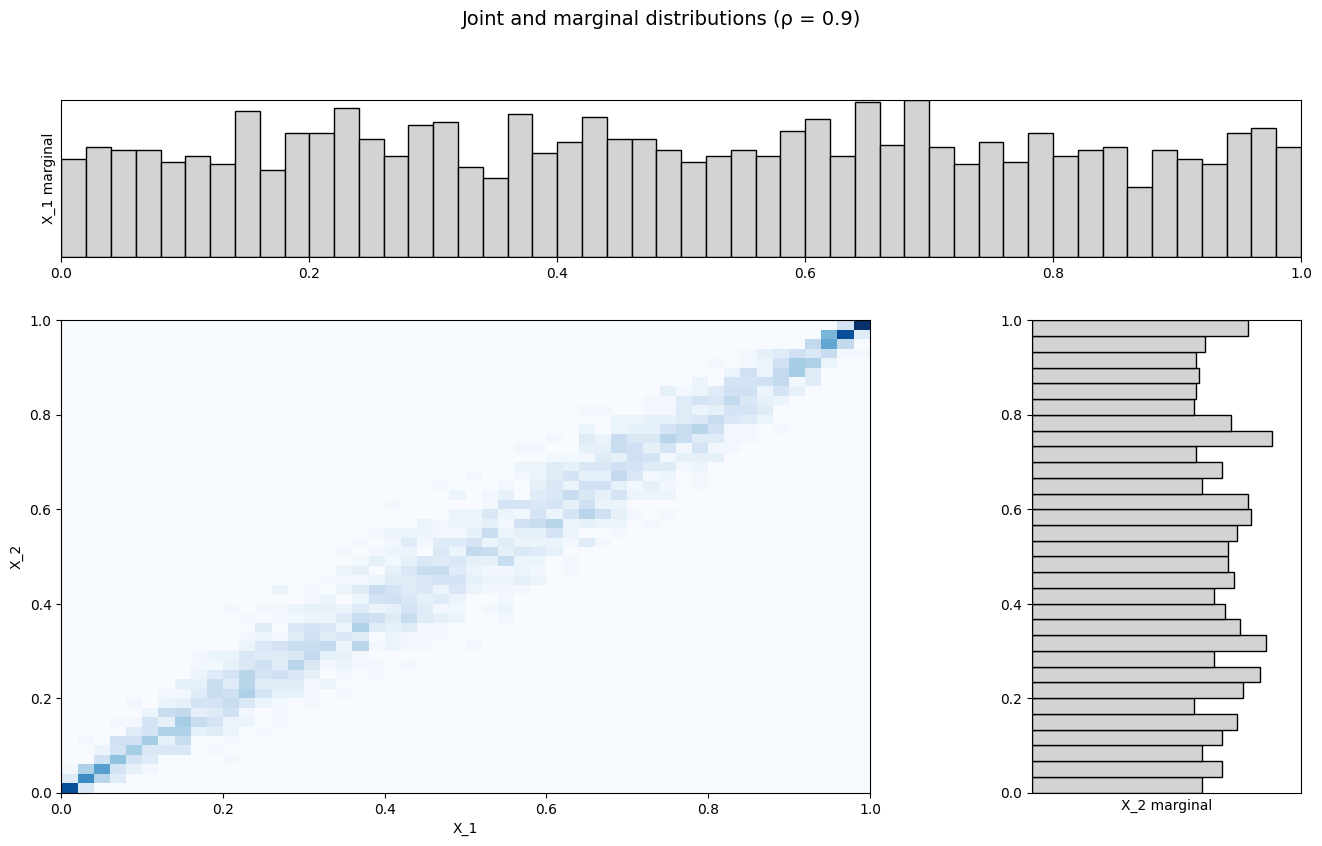

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal


def gaussian_copula_samples(N, rho):
    """Return N pairs (X1, X2) ~ Gaussian copula with correlation rho."""
    rho_z = np.sin(rho * np.pi / 2)

    cov = [[1, rho_z],
           [rho_z, 1]]

    Z = multivariate_normal(mean=[0, 0], cov=cov).rvs(N)

    X1 = norm.cdf(Z[:, 0])
    X2 = norm.cdf(Z[:, 1])

    return X1, X2

N    = 2000
rhos = [0.0, 0.6, 0.9]

#Plot for each rho
for rho in rhos:
    X1, X2 = gaussian_copula_samples(N, rho)

    fig = plt.figure(figsize=(16, 9))
    gs = fig.add_gridspec(2, 2, width_ratios=[3, 1],
                          height_ratios=[1, 3],
                          wspace=0.3, hspace=0.2)

    ax_joint = fig.add_subplot(gs[1, 0])
    ax_joint.scatter(X1, X2, s=2, alpha=0.6,)

    hb = ax_joint.hist2d(X1, X2, bins=50, cmap='Blues', density=True)
    ax_joint.set_xlim(0, 1)
    ax_joint.set_ylim(0, 1)
    ax_joint.set_xlabel('X_1')
    ax_joint.set_ylabel('X_2')

    ax_marg_x1 = fig.add_subplot(gs[0, :], sharex=ax_joint)
    ax_marg_x1.hist(X1, bins=50, density=True, color='lightgray', edgecolor='black')
    ax_marg_x1.set_ylim(0, 1.4)
    ax_marg_x1.set_yticks([])
    ax_marg_x1.set_ylabel('X_1 marginal')
    ax_marg_x1.set_title('')

    ax_marg_x2 = fig.add_subplot(gs[1, 1], sharey=ax_joint)
    ax_marg_x2.hist(X2, bins=30, density=True, orientation='horizontal', color='lightgray', edgecolor='black')
    ax_marg_x2.set_xlim(0, 1.4)
    ax_marg_x2.set_xticks([])
    ax_marg_x2.set_xlabel('X_2 marginal')

    plt.suptitle(f'Joint and marginal distributions (ρ = {rho})', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()